# Modeling

In [1]:
import numpy as np
import pandas as pd

import optuna
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, f1_score, accuracy_score, classification_report
from lightgbm import LGBMClassifier

import warnings
warnings.filterwarnings('ignore')

/Users/yunaaraya/Desktop/eeg-focus-tracker/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
df = pd.read_csv("../data/processed_by_session/all_sessions_normalized.csv")
df.head()

,TP9_theta,TP9_alpha,TP9_beta,TP9_theta_alpha,TP9_beta_alpha,TP9_engagement,AF7_theta,AF7_alpha,AF7_beta,AF7_theta_alpha,...,AF8_engagement,TP10_theta,TP10_alpha,TP10_beta,TP10_theta_alpha,TP10_beta_alpha,TP10_engagement,alpha_asymmetry,label,session
0,1.234471,1.210795,0.978582,0.982733,0.776915,0.851526,1.034322,0.765393,0.863495,1.222779,...,1.181369,1.001467,1.176479,1.089762,0.859498,0.898335,0.992781,-0.554765,1,1
1,0.678074,0.908069,1.327298,0.719753,1.405066,1.727267,0.988014,0.904989,0.983758,0.987863,...,1.013922,0.856766,0.952863,0.925597,0.907871,0.942069,1.016758,1.395709,1,1
2,1.099751,1.048086,1.468173,1.011400,1.346566,1.458644,1.030313,0.818970,1.020682,1.138356,...,0.987976,0.751295,0.777029,1.040647,0.976261,1.298846,1.356943,1.950642,1,1
3,1.033908,1.143660,1.233292,0.871385,1.036612,1.190827,0.743382,0.578643,0.873885,1.162460,...,0.700564,0.878124,0.996854,1.010756,0.889440,0.983345,1.070851,-3.202137,1,1
4,0.758928,1.115262,1.273642,0.655917,1.097786,1.390569,0.773703,0.711743,0.928365,0.983621,...,1.030596,0.823808,1.215817,0.876779,0.684149,0.699380,0.846399,-0.242200,1,1


## Full dataset training

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3832 entries, 0 to 3831
Data columns (total 27 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   TP9_theta         3832 non-null   float64
 1   TP9_alpha         3832 non-null   float64
 2   TP9_beta          3832 non-null   float64
 3   TP9_theta_alpha   3832 non-null   float64
 4   TP9_beta_alpha    3832 non-null   float64
 5   TP9_engagement    3832 non-null   float64
 6   AF7_theta         3832 non-null   float64
 7   AF7_alpha         3832 non-null   float64
 8   AF7_beta          3832 non-null   float64
 9   AF7_theta_alpha   3832 non-null   float64
 10  AF7_beta_alpha    3832 non-null   float64
 11  AF7_engagement    3832 non-null   float64
 12  AF8_theta         3832 non-null   float64
 13  AF8_alpha         3832 non-null   float64
 14  AF8_beta          3832 non-null   float64
 15  AF8_theta_alpha   3832 non-null   float64
 16  AF8_beta_alpha    3832 non-null   float64


In [4]:
scaler = StandardScaler()
X = df.drop(['label', 'session'], axis=1)
X = scaler.fit_transform(X)
y = df['label'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## Random Forest Model

In [5]:
def rf_objective(trial):
    params = {
        # Core structure
        'n_estimators':      trial.suggest_int('n_estimators', 50, 1000, step=50),
        'max_depth':         trial.suggest_int('max_depth', 2, 32, log=True),  # log scale — large range
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
        'min_samples_leaf':  trial.suggest_int('min_samples_leaf', 1, 20),
        'max_features':      trial.suggest_categorical('max_features', ['sqrt', 'log2', 0.3, 0.5, 0.7, None]),

        # Regularisation / leaf purity
        'max_leaf_nodes':    trial.suggest_int('max_leaf_nodes', 10, 1000, log=True),  # or None (unlimited)
        'min_impurity_decrease': trial.suggest_float('min_impurity_decrease', 0.0, 0.2),
        'criterion':         trial.suggest_categorical('criterion', ['gini', 'entropy', 'log_loss']),
    }
    cv = cross_val_score(
        RandomForestClassifier(**params, n_jobs=-1, random_state=42),
        X_train, y_train,
        cv=5, scoring='roc_auc'
    )
    return cv.mean()

### KFold Cross Validation

In [6]:
optuna.logging.set_verbosity(optuna.logging.WARNING)
study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=0))
study.optimize(rf_objective, n_trials=50)
rf_model_k_full = RandomForestClassifier(**study.best_params, n_jobs=-1, random_state=42)
rf_model_k_full.fit(X_train, y_train)

print(f'ROC AUC (test): {roc_auc_score(y_test, rf_model_k_full.predict_proba(X_test)[:, 1]):.4f}')
print(f'ROC AUC (train): {roc_auc_score(y_train, rf_model_k_full.predict_proba(X_train)[:, 1]):.4f}')
print(classification_report(y_test, rf_model_k_full.predict(X_test)))

# save variables for later model comparison
y_proba_rf_k_full = rf_model_k_full.predict_proba(X_test)[:, 1]
y_test_rf_k_full = y_test

ROC AUC (test): 0.6445
ROC AUC (train): 0.8068
              precision    recall  f1-score   support

           0       0.61      0.70      0.65       404
           1       0.60      0.51      0.55       363

    accuracy                           0.61       767
   macro avg       0.61      0.60      0.60       767
weighted avg       0.61      0.61      0.61       767



### LOSO Cross Validation

In [7]:
optuna.logging.set_verbosity(optuna.logging.WARNING)

feature_cols = [c for c in df.columns if c not in ['label', 'session']]
sessions     = sorted(df['session'].unique())
auc_scores   = []
all_y_test       = []
all_y_pred_label = []
all_y_pred_proba = []

for i in sessions:
    # split by session
    test_mask  = df['session'] == i
    train_mask = ~test_mask

    X_train = df.loc[train_mask, feature_cols].values
    y_train = df.loc[train_mask, 'label'].values
    X_test  = df.loc[test_mask,  feature_cols].values
    y_test  = df.loc[test_mask,  'label'].values

    # scale inside the fold, fit only on train
    scaler  = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test  = scaler.transform(X_test) 

    study = optuna.create_study(
        direction='maximize',
        sampler=optuna.samplers.TPESampler(seed=0)
    )
    study.optimize(rf_objective, n_trials=50, show_progress_bar=False)

    # train final model on all training sessions
    rf_model_loso_full = RandomForestClassifier(**study.best_params, n_jobs=-1, random_state=42)
    rf_model_loso_full.fit(X_train, y_train)

    # evaluate on held-out session 
    y_pred_proba = rf_model_loso_full.predict_proba(X_test)[:, 1]
    y_pred_label = rf_model_loso_full.predict(X_test)
    auc = roc_auc_score(y_test, y_pred_proba)
    auc_scores.append(auc)
    print(f'Session {i:02d} held out — AUC: {auc:.4f}')

    all_y_test.extend(y_test)
    all_y_pred_label.extend(y_pred_label)
    all_y_pred_proba.extend(y_pred_proba)

print(f'\nMean AUC : {np.mean(auc_scores):.4f}')
print(f'Std      : {np.std(auc_scores):.4f}')
print(f'Min      : {np.min(auc_scores):.4f}')
print(f'Max      : {np.max(auc_scores):.4f}')
print(classification_report(all_y_test, all_y_pred_label))

# save variables for later model comparison
y_test_rf_loso_full  = np.array(all_y_test)
y_proba_rf_loso_full = np.array(all_y_pred_proba)

Session 01 held out — AUC: 0.7301
Session 02 held out — AUC: 0.5408
Session 03 held out — AUC: 0.5124
Session 04 held out — AUC: 0.5224
Session 05 held out — AUC: 0.5016
Session 06 held out — AUC: 0.4827
Session 07 held out — AUC: 0.2802
Session 08 held out — AUC: 0.6356
Session 09 held out — AUC: 0.5487
Session 10 held out — AUC: 0.5789
Session 11 held out — AUC: 0.6728
Session 12 held out — AUC: 0.6654
Session 13 held out — AUC: 0.4165
Session 14 held out — AUC: 0.4505
Session 15 held out — AUC: 0.7233

Mean AUC : 0.5508
Std      : 0.1180
Min      : 0.2802
Max      : 0.7301
              precision    recall  f1-score   support

           0       0.54      0.78      0.64      2026
           1       0.50      0.25      0.33      1806

    accuracy                           0.53      3832
   macro avg       0.52      0.51      0.48      3832
weighted avg       0.52      0.53      0.49      3832



## LightGBM

In [8]:
def lgbm_objective(trial):
    params = {
        'n_estimators':     trial.suggest_int('n_estimators', 100, 1000),
        'max_depth':        trial.suggest_int('max_depth', 3, 10),
        'learning_rate':    trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'num_leaves':       trial.suggest_int('num_leaves', 20, 150),
        'subsample':        trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'min_child_samples':trial.suggest_int('min_child_samples', 5, 100),
        'random_state': 42,
        'verbose': -1,
    }
    cv = cross_val_score(
        LGBMClassifier(**params),
        X_train, y_train,
        cv=5, scoring='roc_auc'
    )
    return cv.mean()

### KFold Cross Validation

In [9]:
optuna.logging.set_verbosity(optuna.logging.WARNING)
study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=0))
study.optimize(lgbm_objective, n_trials=50)
lgbm_model_k_full = LGBMClassifier(**study.best_params, n_jobs=-1, random_state=42)
lgbm_model_k_full.fit(X_train, y_train)

print(f'ROC AUC (test): {roc_auc_score(y_test, lgbm_model_k_full.predict_proba(X_test)[:, 1]):.4f}')
print(f'ROC AUC (train): {roc_auc_score(y_train, lgbm_model_k_full.predict_proba(X_train)[:, 1]):.4f}')
print(classification_report(y_test, lgbm_model_k_full.predict(X_test)))

# save variables for later model comparison
y_proba_lgbm_k_full = lgbm_model_k_full.predict_proba(X_test)[:, 1]
y_test_lgbm_k_full = y_test

ROC AUC (test): 0.7004
ROC AUC (train): 0.6959
              precision    recall  f1-score   support

           0       0.60      0.97      0.74       142
           1       0.82      0.17      0.27       109

    accuracy                           0.62       251
   macro avg       0.71      0.57      0.51       251
weighted avg       0.70      0.62      0.54       251



### LOSO Cross Validation

In [10]:
feature_cols = [c for c in df.columns if c not in ['label', 'session']]
sessions     = sorted(df['session'].unique())
auc_scores   = []
all_y_test       = []
all_y_pred_label = []
all_y_pred_proba = []

for i in sessions:
    # split by session
    test_mask  = df['session'] == i
    train_mask = ~test_mask

    X_train = df.loc[train_mask, feature_cols].values
    y_train = df.loc[train_mask, 'label'].values
    X_test  = df.loc[test_mask,  feature_cols].values
    y_test  = df.loc[test_mask,  'label'].values

    # scale inside the fold, fit only on train
    scaler  = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test  = scaler.transform(X_test) 

    study = optuna.create_study(
        direction='maximize',
        sampler=optuna.samplers.TPESampler(seed=0)
    )
    study.optimize(lgbm_objective, n_trials=50, show_progress_bar=False)

    # train final model on all training sessions
    lgbm_model_loso_full = LGBMClassifier(**study.best_params, random_state=42, verbose=-1)
    lgbm_model_loso_full.fit(X_train, y_train)

    # evaluate on held-out session — exactly once
    y_pred_proba = lgbm_model_loso_full.predict_proba(X_test)[:, 1]
    y_pred_label = lgbm_model_loso_full.predict(X_test)
    auc = roc_auc_score(y_test, y_pred_proba)
    auc_scores.append(auc)
    print(f'Session {i:02d} held out — AUC: {auc:.4f}')

    all_y_test.extend(y_test)
    all_y_pred_label.extend(y_pred_label)
    all_y_pred_proba.extend(y_pred_proba)

print(f'\nMean AUC : {np.mean(auc_scores):.4f}')
print(f'Std      : {np.std(auc_scores):.4f}')
print(f'Min      : {np.min(auc_scores):.4f}')
print(f'Max      : {np.max(auc_scores):.4f}')
print(classification_report(all_y_test, all_y_pred_label))

# save variables for later model comparison
y_test_lgbm_loso_full  = np.array(all_y_test)
y_proba_lgbm_loso_full = np.array(all_y_pred_proba)

Session 01 held out — AUC: 0.6777
Session 02 held out — AUC: 0.5677
Session 03 held out — AUC: 0.5142
Session 04 held out — AUC: 0.5384
Session 05 held out — AUC: 0.4960
Session 06 held out — AUC: 0.4558
Session 07 held out — AUC: 0.2762
Session 08 held out — AUC: 0.6170
Session 09 held out — AUC: 0.5283
Session 10 held out — AUC: 0.5919
Session 11 held out — AUC: 0.6949
Session 12 held out — AUC: 0.5812
Session 13 held out — AUC: 0.4844
Session 14 held out — AUC: 0.5605
Session 15 held out — AUC: 0.7004

Mean AUC : 0.5523
Std      : 0.1034
Min      : 0.2762
Max      : 0.7004
              precision    recall  f1-score   support

           0       0.56      0.67      0.61      2026
           1       0.52      0.41      0.46      1806

    accuracy                           0.54      3832
   macro avg       0.54      0.54      0.53      3832
weighted avg       0.54      0.54      0.54      3832



## SVM

In [11]:
from sklearn.svm import SVC

def svm_objective(trial):
    params = {
        'C':     trial.suggest_float('C', 0.01, 100, log=True),
        'gamma': trial.suggest_float('gamma', 0.001, 1.0, log=True),
    }
    cv = cross_val_score(
        SVC(**params, kernel='rbf', probability=True, random_state=42),
        X_train, y_train, 
        cv=5, scoring='roc_auc'
    )
    return cv.mean()

### KFold Cross Validation

In [12]:
optuna.logging.set_verbosity(optuna.logging.WARNING)
study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=0))
study.optimize(svm_objective, n_trials=50)
svm_model_k_full = SVC(**study.best_params, kernel='rbf', probability=True, random_state=42)
svm_model_k_full.fit(X_train, y_train)

print(f'ROC AUC (test): {roc_auc_score(y_test, svm_model_k_full.predict_proba(X_test)[:, 1]):.4f}')
print(f'ROC AUC (train): {roc_auc_score(y_train, svm_model_k_full.predict_proba(X_train)[:, 1]):.4f}')
print(classification_report(y_test, svm_model_k_full.predict(X_test)))

# save variables for later model comparison
y_proba_svm_k_full = svm_model_k_full.predict_proba(X_test)[:, 1]
y_test_svm_k_full = y_test

ROC AUC (test): 0.8093
ROC AUC (train): 0.6514
              precision    recall  f1-score   support

           0       0.61      0.98      0.75       142
           1       0.86      0.17      0.29       109

    accuracy                           0.63       251
   macro avg       0.74      0.58      0.52       251
weighted avg       0.72      0.63      0.55       251



### LOSO Cross Validation

In [13]:
feature_cols = [c for c in df.columns if c not in ['label', 'session']]
sessions     = sorted(df['session'].unique())
auc_scores   = []
all_y_test       = []
all_y_pred_label = []
all_y_pred_proba = []

for i in sessions:
    # split by session
    test_mask  = df['session'] == i
    train_mask = ~test_mask

    X_train = df.loc[train_mask, feature_cols].values
    y_train = df.loc[train_mask, 'label'].values
    X_test  = df.loc[test_mask,  feature_cols].values
    y_test  = df.loc[test_mask,  'label'].values

    # scale inside the fold, fit only on train
    scaler  = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test  = scaler.transform(X_test) 

    study = optuna.create_study(
        direction='maximize',
        sampler=optuna.samplers.TPESampler(seed=0)
    )
    study.optimize(svm_objective, n_trials=50, show_progress_bar=False)

    # train final model on all training sessions
    svm_model_loso_full = SVC(**study.best_params, probability=True, random_state=42)
    svm_model_loso_full.fit(X_train, y_train)

    # evaluate on held-out session — exactly once
    y_pred_proba = svm_model_loso_full.predict_proba(X_test)[:, 1]
    y_pred_label = svm_model_loso_full.predict(X_test)
    auc = roc_auc_score(y_test, y_pred_proba)
    auc_scores.append(auc)
    print(f'Session {i:02d} held out — AUC: {auc:.4f}')

    all_y_test.extend(y_test)
    all_y_pred_label.extend(y_pred_label)
    all_y_pred_proba.extend(y_pred_proba)

print(f'\nMean AUC : {np.mean(auc_scores):.4f}')
print(f'Std      : {np.std(auc_scores):.4f}')
print(f'Min      : {np.min(auc_scores):.4f}')
print(f'Max      : {np.max(auc_scores):.4f}')
print(classification_report(all_y_test, all_y_pred_label))

# save variables for later model comparison
y_test_svm_loso_full  = np.array(all_y_test)
y_proba_svm_loso_full = np.array(all_y_pred_proba)

Session 01 held out — AUC: 0.7463
Session 02 held out — AUC: 0.6321
Session 03 held out — AUC: 0.4434
Session 04 held out — AUC: 0.5547
Session 05 held out — AUC: 0.4771
Session 06 held out — AUC: 0.4852
Session 07 held out — AUC: 0.2824
Session 08 held out — AUC: 0.6702
Session 09 held out — AUC: 0.5281
Session 10 held out — AUC: 0.5825
Session 11 held out — AUC: 0.7030
Session 12 held out — AUC: 0.5726
Session 13 held out — AUC: 0.4322
Session 14 held out — AUC: 0.5555
Session 15 held out — AUC: 0.8093

Mean AUC : 0.5650
Std      : 0.1305
Min      : 0.2824
Max      : 0.8093
              precision    recall  f1-score   support

           0       0.56      0.66      0.61      2026
           1       0.52      0.42      0.47      1806

    accuracy                           0.55      3832
   macro avg       0.54      0.54      0.54      3832
weighted avg       0.54      0.55      0.54      3832



## Clean dataset training - leaving out sessions with high noise

In [14]:
# leave session 4, 7, 8 out for training (see 02_exploratory for more details)
df_clean = df[~(df['session'] == 4) & ~(df['session'] == 7) & ~(df['session'] == 8)]
print(df_clean['session'].unique())
print(len(df_clean))

[ 1  2  3  5  6  9 10 11 12 13 14 15]
3112


In [15]:
scaler = StandardScaler()
X = df_clean.drop(['label', 'session'], axis=1)
X = scaler.fit_transform(X)
y = df_clean['label'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### SVM

In [16]:
optuna.logging.set_verbosity(optuna.logging.WARNING)
study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=0))
study.optimize(svm_objective, n_trials=50)
svm_model_k_clean = SVC(**study.best_params, probability=True,random_state=42)
svm_model_k_clean.fit(X_train, y_train)

print(f'ROC AUC (test): {roc_auc_score(y_test, svm_model_k_clean.predict_proba(X_test)[:, 1]):.4f}')
print(f'ROC AUC (train): {roc_auc_score(y_train, svm_model_k_clean.predict_proba(X_train)[:, 1]):.4f}')
print(classification_report(y_test, svm_model_k_clean.predict(X_test)))

# save variables for later model comparison
y_proba_svm_k_clean = svm_model_k_clean.predict_proba(X_test)[:, 1]
y_test_svm_k_clean = y_test

ROC AUC (test): 0.6935
ROC AUC (train): 0.7362
              precision    recall  f1-score   support

           0       0.61      0.72      0.66       305
           1       0.67      0.56      0.61       318

    accuracy                           0.64       623
   macro avg       0.64      0.64      0.63       623
weighted avg       0.64      0.64      0.63       623



In [17]:
feature_cols = [c for c in df_clean.columns if c not in ['label', 'session']]
sessions     = sorted(df_clean['session'].unique())
auc_scores   = []
all_y_test       = []
all_y_pred_label = []
all_y_pred_proba = []

for i in sessions:
    # split by session
    test_mask  = df_clean['session'] == i
    train_mask = ~test_mask

    X_train = df_clean.loc[train_mask, feature_cols].values
    y_train = df_clean.loc[train_mask, 'label'].values
    X_test  = df_clean.loc[test_mask,  feature_cols].values
    y_test  = df_clean.loc[test_mask,  'label'].values

    # scale inside the fold, fit only on train
    scaler  = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test  = scaler.transform(X_test) 

    study = optuna.create_study(
        direction='maximize',
        sampler=optuna.samplers.TPESampler(seed=0)
    )
    study.optimize(svm_objective, n_trials=50, show_progress_bar=False)

    # train final model on all training sessions
    svm_model_loso_clean = SVC(**study.best_params, probability=True, random_state=42)
    svm_model_loso_clean.fit(X_train, y_train)

    # evaluate on held-out session — exactly once
    y_pred_proba = svm_model_loso_clean.predict_proba(X_test)[:, 1]
    y_pred_label = svm_model_loso_clean.predict(X_test)
    auc = roc_auc_score(y_test, y_pred_proba)
    auc_scores.append(auc)
    print(f'Session {i:02d} held out — AUC: {auc:.4f}')

    all_y_test.extend(y_test)
    all_y_pred_label.extend(y_pred_label)
    all_y_pred_proba.extend(y_pred_proba)

print(f'\nMean AUC : {np.mean(auc_scores):.4f}')
print(f'Std      : {np.std(auc_scores):.4f}')
print(f'Min      : {np.min(auc_scores):.4f}')
print(f'Max      : {np.max(auc_scores):.4f}')
print(classification_report(all_y_test, all_y_pred_label))

# save variables for later model comparison
y_test_svm_loso_clean  = np.array(all_y_test)
y_proba_svm_loso_clean = np.array(all_y_pred_proba)

Session 01 held out — AUC: 0.8118
Session 02 held out — AUC: 0.5642
Session 03 held out — AUC: 0.4829
Session 05 held out — AUC: 0.4405
Session 06 held out — AUC: 0.4964
Session 09 held out — AUC: 0.4796
Session 10 held out — AUC: 0.6023
Session 11 held out — AUC: 0.7356
Session 12 held out — AUC: 0.5628
Session 13 held out — AUC: 0.5737
Session 14 held out — AUC: 0.4960
Session 15 held out — AUC: 0.8123

Mean AUC : 0.5882
Std      : 0.1242
Min      : 0.4405
Max      : 0.8123
              precision    recall  f1-score   support

           0       0.56      0.68      0.61      1621
           1       0.54      0.41      0.47      1491

    accuracy                           0.55      3112
   macro avg       0.55      0.54      0.54      3112
weighted avg       0.55      0.55      0.54      3112



### LightGBM

In [18]:
optuna.logging.set_verbosity(optuna.logging.WARNING)
study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=0))
study.optimize(lgbm_objective, n_trials=50)
lgbm_model_k_clean = LGBMClassifier(**study.best_params, n_jobs=-1, random_state=42)
lgbm_model_k_clean.fit(X_train, y_train)

print(f'ROC AUC (test): {roc_auc_score(y_test, lgbm_model_k_clean.predict_proba(X_test)[:, 1]):.4f}')
print(f'ROC AUC (train): {roc_auc_score(y_train, lgbm_model_k_clean.predict_proba(X_train)[:, 1]):.4f}')
print(classification_report(y_test, lgbm_model_k_clean.predict(X_test)))

# save variables for later model comparison
y_proba_lgbm_k_clean = lgbm_model_k_clean.predict_proba(X_test)[:, 1]
y_test_lgbm_k_clean = y_test

ROC AUC (test): 0.7586
ROC AUC (train): 0.7154
              precision    recall  f1-score   support

           0       0.63      0.96      0.77       142
           1       0.86      0.28      0.42       109

    accuracy                           0.67       251
   macro avg       0.75      0.62      0.59       251
weighted avg       0.73      0.67      0.61       251



In [20]:
feature_cols = [c for c in df.columns if c not in ['label', 'session']]
sessions     = sorted(df_clean['session'].unique())
auc_scores   = []
all_y_test       = []
all_y_pred_label = []
all_y_pred_proba = []

for i in sessions:
    # split by session
    test_mask  = df_clean['session'] == i
    train_mask = ~test_mask

    X_train = df_clean.loc[train_mask, feature_cols].values
    y_train = df_clean.loc[train_mask, 'label'].values
    X_test  = df_clean.loc[test_mask,  feature_cols].values
    y_test  = df_clean.loc[test_mask,  'label'].values

    # scale inside the fold, fit only on train
    scaler  = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test  = scaler.transform(X_test) 

    study = optuna.create_study(
        direction='maximize',
        sampler=optuna.samplers.TPESampler(seed=0)
    )
    study.optimize(lgbm_objective, n_trials=50, show_progress_bar=False)

    # train final model on all training sessions
    lgbm_model_loso_clean = LGBMClassifier(**study.best_params, random_state=42, verbose=-1)
    lgbm_model_loso_clean.fit(X_train, y_train)

    # evaluate on held-out session — exactly once
    y_pred_proba = lgbm_model_loso_clean.predict_proba(X_test)[:, 1]
    y_pred_label = lgbm_model_loso_clean.predict(X_test)
    auc = roc_auc_score(y_test, y_pred_proba)
    auc_scores.append(auc)
    print(f'Session {i:02d} held out — AUC: {auc:.4f}')

    all_y_test.extend(y_test)
    all_y_pred_label.extend(y_pred_label)
    all_y_pred_proba.extend(y_pred_proba)

print(f'\nMean AUC : {np.mean(auc_scores):.4f}')
print(f'Std      : {np.std(auc_scores):.4f}')
print(f'Min      : {np.min(auc_scores):.4f}')
print(f'Max      : {np.max(auc_scores):.4f}')
print(classification_report(all_y_test, all_y_pred_label))

# save variables for later model comparison
y_test_lgbm_loso_clean  = np.array(all_y_test)
y_proba_lgbm_loso_clean = np.array(all_y_pred_proba)

Session 01 held out — AUC: 0.7627
Session 02 held out — AUC: 0.5270
Session 03 held out — AUC: 0.5962
Session 05 held out — AUC: 0.4568
Session 06 held out — AUC: 0.4681
Session 09 held out — AUC: 0.5121
Session 10 held out — AUC: 0.6000
Session 11 held out — AUC: 0.7556
Session 12 held out — AUC: 0.6843
Session 13 held out — AUC: 0.5221
Session 14 held out — AUC: 0.5291
Session 15 held out — AUC: 0.7586

Mean AUC : 0.5977
Std      : 0.1099
Min      : 0.4568
Max      : 0.7627
              precision    recall  f1-score   support

           0       0.58      0.64      0.61      1621
           1       0.56      0.49      0.52      1491

    accuracy                           0.57      3112
   macro avg       0.57      0.57      0.57      3112
weighted avg       0.57      0.57      0.57      3112



## Feature selection - optimizing the features for training

In [21]:
import numpy as np
import optuna
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.model_selection import cross_val_score
from sklearn.metrics import roc_auc_score, classification_report
from sklearn.svm import SVC

optuna.logging.set_verbosity(optuna.logging.WARNING)

feature_cols = [c for c in df_clean.columns if c not in ['label', 'session']]
sessions     = sorted(df_clean['session'].unique())
auc_scores   = []
all_y_test   = []
all_y_pred   = []
all_y_proba  = []

for i in sessions:
    # ── Step 1: split by session ────────────────────────────────────────
    test_mask  = df_clean['session'] == i
    train_mask = ~test_mask

    X_train = df_clean.loc[train_mask, feature_cols].values
    y_train = df_clean.loc[train_mask, 'label'].values
    X_test  = df_clean.loc[test_mask,  feature_cols].values
    y_test  = df_clean.loc[test_mask,  'label'].values

    # ── Step 2: scale inside fold, fit only on train ────────────────────
    scaler  = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test  = scaler.transform(X_test)

    # ── Step 3: Optuna tunes C, gamma, AND k together ───────────────────
    def svm_objective(trial):
        # tune number of features to keep
        k = trial.suggest_int('k', 20, len(feature_cols))

        # fit selector on train only, inside the trial
        sel = SelectKBest(score_func=f_classif, k=k)
        sel.fit(X_train, y_train)
        X_tr_sel = sel.transform(X_train)

        # tune SVM hyperparameters
        params = {
            'C':     trial.suggest_float('C',     0.01, 100,  log=True),
            'gamma': trial.suggest_float('gamma', 0.001, 1.0, log=True),
        }
        return cross_val_score(
            SVC(**params, kernel='rbf', probability=True, random_state=42),
            X_tr_sel, y_train,
            cv=5, scoring='roc_auc'
        ).mean()

    study = optuna.create_study(
        direction='maximize',
        sampler=optuna.samplers.TPESampler(seed=42)
    )
    study.optimize(svm_objective, n_trials=50, show_progress_bar=False)

    # ── Step 4: extract best params and re-fit selector ─────────────────
    best_params = study.best_params.copy()
    best_k      = best_params.pop('k')          # separate k from SVM params

    selector = SelectKBest(score_func=f_classif, k=best_k)
    selector.fit(X_train, y_train)              # re-fit with best k on full train
    X_train_sel = selector.transform(X_train)
    X_test_sel  = selector.transform(X_test)

    # ── Step 5: train final model on selected features ───────────────────
    svm_model_feature = SVC(**best_params, kernel='rbf', probability=True, random_state=42)
    svm_model_feature.fit(X_train_sel, y_train)

    # ── Step 6: evaluate on held-out session — exactly once ─────────────
    y_pred_proba = svm_model_feature.predict_proba(X_test_sel)[:, 1]
    y_pred_label = svm_model_feature.predict(X_test_sel)
    auc          = roc_auc_score(y_test, y_pred_proba)

    auc_scores.append(auc)
    all_y_test.extend(y_test)
    all_y_pred.extend(y_pred_label)
    all_y_proba.extend(y_pred_proba)

    print(f'Session {i:02d} held out — AUC: {auc:.4f}  '
          f'| features kept: {best_k}/{len(feature_cols)}  '
          f'| C: {best_params["C"]:.4f}  gamma: {best_params["gamma"]:.4f}')

# ── Summary ──────────────────────────────────────────────────────────────
print(f'\nMean AUC : {np.mean(auc_scores):.4f}')
print(f'Std      : {np.std(auc_scores):.4f}')
print(f'Min      : {np.min(auc_scores):.4f}')
print(f'Max      : {np.max(auc_scores):.4f}')

print(classification_report(all_y_test, all_y_pred))

# save variables for later model comparison
y_test_svm_loso_feature  = np.array(all_y_test)
y_proba_svm_loso_feature = np.array(all_y_proba)

Session 01 held out — AUC: 0.8003  | features kept: 20/25  | C: 0.8663  gamma: 0.0057
Session 02 held out — AUC: 0.5631  | features kept: 23/25  | C: 1.4059  gamma: 0.0027
Session 03 held out — AUC: 0.4761  | features kept: 22/25  | C: 0.7308  gamma: 0.0027
Session 05 held out — AUC: 0.4399  | features kept: 21/25  | C: 4.0503  gamma: 0.0018
Session 06 held out — AUC: 0.5046  | features kept: 20/25  | C: 0.5780  gamma: 0.0027
Session 09 held out — AUC: 0.4520  | features kept: 20/25  | C: 0.2923  gamma: 0.0011
Session 10 held out — AUC: 0.5993  | features kept: 20/25  | C: 2.1342  gamma: 0.0013
Session 11 held out — AUC: 0.7146  | features kept: 20/25  | C: 0.0109  gamma: 0.0015
Session 12 held out — AUC: 0.6058  | features kept: 20/25  | C: 0.2181  gamma: 0.0011
Session 13 held out — AUC: 0.4484  | features kept: 20/25  | C: 0.0198  gamma: 0.0010
Session 14 held out — AUC: 0.5073  | features kept: 22/25  | C: 16.2919  gamma: 0.0013
Session 15 held out — AUC: 0.8034  | features kept: 2

In [22]:
print(f'Best feature number: {best_k}')

Best feature number: 20


## Feature Importance - LightGBM Model, LOSO CV, clean dataset

<Axes: xlabel='importance', ylabel='feature'>

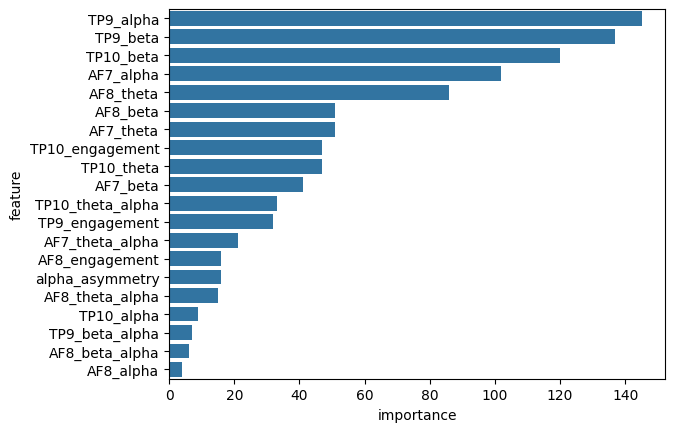

In [26]:
import seaborn as sns
feature_importance_df = pd.DataFrame({
    'feature': feature_cols,
    'importance': lgbm_model_k_clean.feature_importances_
}).sort_values('importance', ascending=False).head(20)

sns.barplot(y=feature_importance_df['feature'], x=feature_importance_df['importance'])


### Top 5 features

In [28]:
feature_importance = pd.DataFrame({'feature': feature_cols, 'importance': lgbm_model_k_clean.feature_importances_})
feature_importance.sort_values(by='importance', ascending=False, inplace=True)
feature_importance.head()

,feature,importance
1,TP9_alpha,145
2,TP9_beta,137
20,TP10_beta,120
7,AF7_alpha,102
12,AF8_theta,86


## Model Results Comparison

In [29]:
model_results = {
    'RF (KFold, full)':        (y_test_rf_k_full,    y_proba_rf_k_full),
    'RF (LOSO, full)':         (y_test_rf_loso_full, y_proba_rf_loso_full),
    'LightGBM (KFold, full)':  (y_test_lgbm_k_full,  y_proba_lgbm_k_full),
    'LightGBM (LOSO, full)':   (y_test_lgbm_loso_full, y_proba_lgbm_loso_full),
    'SVM (KFold, full)':       (y_test_svm_k_full,   y_proba_svm_k_full),
    'SVM (LOSO, full)':        (y_test_svm_loso_full, y_proba_svm_loso_full),
    'LightGBM (KFold, clean)': (y_test_lgbm_k_clean, y_proba_lgbm_k_clean),
    'LightGBM (LOSO, clean)':  (y_test_lgbm_loso_clean, y_proba_lgbm_loso_clean),
    'SVM (KFold, clean)':      (y_test_svm_k_clean,  y_proba_svm_k_clean),
    'SVM (LOSO, clean)':       (y_test_svm_loso_clean, y_proba_svm_loso_clean),
    'SVM (feature selection)': (y_test_svm_loso_feature,  y_proba_svm_loso_feature),
}

rows = []
for name, (y_true, y_proba) in model_results.items():
    y_pred = (y_proba >= 0.5).astype(int)  # 確率→0/1に変換

    rows.append({
        'model': name,
        'roc_auc':  roc_auc_score(y_true, y_proba),
        'f1':       f1_score(y_true, y_pred),
        'accuracy': accuracy_score(y_true, y_pred),
    })

model_vals = pd.DataFrame(rows).sort_values('roc_auc', ascending=False)
model_vals = model_vals.round(3)
print(model_vals.to_string(index=False))

model_vals.style.background_gradient(subset=['roc_auc', 'f1', 'accuracy'], cmap='Greens')

                  model  roc_auc    f1  accuracy
      SVM (KFold, full)    0.809 0.316     0.637
LightGBM (KFold, clean)    0.759 0.417     0.665
 LightGBM (KFold, full)    0.700 0.275     0.622
     SVM (KFold, clean)    0.694 0.607     0.636
       RF (KFold, full)    0.644 0.554     0.609
 LightGBM (LOSO, clean)    0.587 0.524     0.570
      SVM (LOSO, clean)    0.574 0.519     0.556
       SVM (LOSO, full)    0.568 0.501     0.550
  LightGBM (LOSO, full)    0.561 0.456     0.544
SVM (feature selection)    0.560 0.526     0.548
        RF (LOSO, full)    0.530 0.331     0.529


,model,roc_auc,f1,accuracy
4,"SVM (KFold, full)",0.809000,0.316000,0.637000
6,"LightGBM (KFold, clean)",0.759000,0.417000,0.665000
2,"LightGBM (KFold, full)",0.700000,0.275000,0.622000
8,"SVM (KFold, clean)",0.694000,0.607000,0.636000
0,"RF (KFold, full)",0.644000,0.554000,0.609000
7,"LightGBM (LOSO, clean)",0.587000,0.524000,0.570000
9,"SVM (LOSO, clean)",0.574000,0.519000,0.556000
5,"SVM (LOSO, full)",0.568000,0.501000,0.550000
3,"LightGBM (LOSO, full)",0.561000,0.456000,0.544000
10,SVM (feature selection),0.560000,0.526000,0.548000


### KFold vs LOSO: Evidence of Session-Level Leakage

A substantial gap was observed between standard K-Fold CV and
Leave-One-Session-Out (LOSO) CV across all models:

| Model | KFold AUC | LOSO AUC | Gap |
|-------|-----------|----------|-----|
| SVM (full)      | 0.809 | 0.568 | 0.241 |
| LightGBM (full) | 0.700 | 0.561 | 0.139 |

This gap indicates that K-Fold CV substantially overestimates real-world
performance, because EEG windows from the same session share session-level
characteristics (electrode contact, time-of-day state) that leak between
train and test splits when split at the window level.

**LOSO is therefore treated as the primary evaluation metric for this
project**, since it evaluates generalization to genuinely unseen sessions —
which matches the real-world deployment scenario (a new session each time
the headset is worn).

### Summary
- Overall, **LightGBM using clean dataset performed best**（ROC-AUC 0.587; F1 0.524; Accuracy 0.570）based on LOSO CV.
- Random Forest model performed significantly worse than other models, indicating the model's limited capability in cross-session generalization.
- Feature selection was not effective in improving model performance.
- Clean dataset training performed better than full dataset training, though the effect was limited.

## Best Model = LightGBM - LOSO, clean dataset, full feature

In [31]:
# best model = LightGBM (LOSO, clean dataset, full feature)
focus_model = lgbm_model_loso_clean

In [32]:
# export best model for application
import pickle
pickle.dump(focus_model, open('../models/focus_model.pkl', 'wb'))
pickle.dump(feature_cols, open('../models/feature_names.pkl', 'wb'))
pickle.dump(scaler, open('../models/scaler.pkl', 'wb'))